# DeepLense GSoC 2026 — Specific Test II: Agentic AI

## Overview

We implement an **agentic workflow** using **Pydantic AI + Groq (Llama 3)** that wraps
the DeepLenseSim simulation pipeline. The agent accepts natural language prompts, asks clarifying
questions (human-in-the-loop), and orchestrates DeepLenseSim to generate strong gravitational
lensing images with structured metadata.

### Models supported (all share the same 3 DM classes)
| Model | Size | Telescope |
|---|---|---|
| Model_I   | 150×150 | Generic Gaussian PSF |
| Model_II  | 64×64   | Euclid |
| Model_III | 64×64   | HST |
| Model_IV  | 64×64   | Euclid + real galaxy sources |

In [1]:
import os, sys, re, time, asyncio
import nest_asyncio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from typing import Optional, Literal
from enum import Enum
from pathlib import Path

from pydantic_ai import Agent, RunContext
from pydantic_ai.models.groq import GroqModel
from pydantic import BaseModel, Field, field_validator, model_validator

nest_asyncio.apply()   # allow asyncio.run() inside Jupyter

print('✓ All imports successful')
print(f'Python: {sys.version.split()[0]}')


✓ All imports successful
Python: 3.10.20


In [2]:
class ModelVersion(str, Enum):
    MODEL_I   = "Model_I"
    MODEL_II  = "Model_II"
    MODEL_III = "Model_III"
    MODEL_IV  = "Model_IV"


class SubstructureType(str, Enum):
    NO_SUBSTRUCTURE = "no_substructure"
    AXION           = "axion"
    CDM             = "cdm"


class NoiseModel(str, Enum):
    GAUSSIAN            = "gaussian"
    GAUSSIAN_POISSONIAN = "gaussian_poissonian"
    NONE                = "none"


class LensParameters(BaseModel):
    z_lens:           float = Field(default=0.5,  ge=0.01, le=2.0)
    z_source:         float = Field(default=1.5,  ge=0.1,  le=5.0)
    einstein_radius:  float = Field(default=1.0,  ge=0.1,  le=3.0)
    lens_ellipticity: float = Field(default=0.1,  ge=0.0,  le=0.5)

    @model_validator(mode='after')
    def source_behind_lens(self):
        if self.z_source <= self.z_lens:
            raise ValueError(f'z_source ({self.z_source}) must be > z_lens ({self.z_lens})')
        return self


class ObservationParameters(BaseModel):
    pixel_scale:   float      = Field(default=0.101,  ge=0.01, le=1.0)
    image_size:    int        = Field(default=150,    ge=32,   le=512)
    exposure_time: float      = Field(default=1800.0, ge=1.0)
    noise_model:   NoiseModel = Field(default=NoiseModel.GAUSSIAN_POISSONIAN)
    psf_fwhm:      float      = Field(default=0.18,   ge=0.05, le=2.0)
    snr:           float      = Field(default=25.0,   ge=1.0,  le=100.0)
    telescope:     str        = Field(default="generic")


class SimulationConfig(BaseModel):
    model_version:     ModelVersion          = Field(default=ModelVersion.MODEL_I)
    substructure_type: SubstructureType      = Field(default=SubstructureType.NO_SUBSTRUCTURE)
    num_images:        int                   = Field(default=5, ge=1, le=100)
    lens_params:       LensParameters        = Field(default_factory=LensParameters)
    obs_params:        ObservationParameters = Field(default_factory=ObservationParameters)
    random_seed:       Optional[int]         = Field(default=None)
    output_dir:        str                   = Field(default='./simulated_images')

    def summary(self) -> str:
        return (
            f"Model: {self.model_version.value} | "
            f"Substructure: {self.substructure_type.value} | "
            f"Images: {self.num_images} | "
            f"z_lens={self.lens_params.z_lens}, z_src={self.lens_params.z_source} | "
            f"Size: {self.obs_params.image_size}px | "
            f"Telescope: {self.obs_params.telescope}"
        )


class ValidationResult(BaseModel):
    is_valid:    bool
    warnings:    list[str] = Field(default_factory=list)
    errors:      list[str] = Field(default_factory=list)
    suggestions: list[str] = Field(default_factory=list)


class SimulatedImage(BaseModel):
    image_id:          int
    filename:          str
    substructure_type: str
    model_version:     str
    z_lens:            float
    z_source:          float
    einstein_radius:   float
    image_shape:       tuple[int, int]
    pixel_scale:       str
    snr:               float
    noise_model:       str
    telescope:         str
    generated_at:      str

    @field_validator('image_shape')
    @classmethod
    def must_be_2d(cls, v):
        if len(v) != 2:
            raise ValueError(f'image_shape must be 2-D (H, W), got {v}')
        return v


class SimulationResult(BaseModel):
    status:             Literal['success', 'partial', 'failed', 'cancelled']
    config_used:        SimulationConfig
    images_generated:   int
    images_metadata:    list[SimulatedImage]
    output_directory:   str
    total_time_seconds: float
    agent_reasoning:    str
    warnings:           list[str] = Field(default_factory=list)


print('✓ All Pydantic models defined')
print(f'  Models:        {[m.value for m in ModelVersion]}')
print(f'  Substructures: {[s.value for s in SubstructureType]}')


✓ All Pydantic models defined
  Models:        ['Model_I', 'Model_II', 'Model_III', 'Model_IV']
  Substructures: ['no_substructure', 'axion', 'cdm']


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numba
if not hasattr(numba, 'generated_jit'):
    numba.generated_jit = lambda *args, **kwargs: (lambda f: f)

try:
    from lenstronomy.LightModel.light_model import LightModel
    from lenstronomy.LensModel.lens_model import LensModel
    from lenstronomy.ImSim.image_model import ImageModel
    from lenstronomy.Data.imaging_data import ImageData
    from lenstronomy.Data.psf import PSF
    from lenstronomy.Util.simulation_util import data_configure_simple
    from lenstronomy.Util.kernel_util import kernel_gaussian
    LENSTRONOMY_AVAILABLE = True
    print('✓ lenstronomy available — using real simulation')
except Exception as e:
    LENSTRONOMY_AVAILABLE = False
    print(f'⚠ lenstronomy unavailable ({e}) — using physics-informed mock')


class DeepLenseSimEngine:
    MODEL_CONFIGS = {
        ModelVersion.MODEL_I: {
            'description': 'Generic: Gaussian PSF, SNR~25',
            'telescope':   'Generic',
            'image_size':  150,
            'pixel_scale': 0.101,
            'psf_fwhm':    0.18,
            'snr':         25.0,
            'substructures': list(SubstructureType),
        },
        ModelVersion.MODEL_II: {
            'description': 'Euclid survey',
            'telescope':   'Euclid',
            'image_size':  64,
            'pixel_scale': 0.101,
            'psf_fwhm':    0.16,
            'snr':         20.0,
            'substructures': list(SubstructureType),
        },
        ModelVersion.MODEL_III: {
            'description': 'HST survey',
            'telescope':   'HST',
            'image_size':  64,
            'pixel_scale': 0.05,
            'psf_fwhm':    0.08,
            'snr':         30.0,
            'substructures': list(SubstructureType),
        },
        ModelVersion.MODEL_IV: {
            'description': 'Euclid + real galaxy sources',
            'telescope':   'Euclid (real sources)',
            'image_size':  64,
            'pixel_scale': 0.101,
            'psf_fwhm':    0.16,
            'snr':         20.0,
            'substructures': list(SubstructureType),
        },
    }

    def __init__(self):
        self.use_real = LENSTRONOMY_AVAILABLE

    def _apply_model_defaults(self, config: SimulationConfig) -> SimulationConfig:
        cfg = self.MODEL_CONFIGS[config.model_version]
        new_obs = config.obs_params.model_copy(update={
            'pixel_scale': cfg['pixel_scale'],
            'image_size':  cfg['image_size'] if config.obs_params.image_size == 150
                           else config.obs_params.image_size,
            'psf_fwhm':    cfg['psf_fwhm'],
            'telescope':   cfg['telescope'],
        })
        return config.model_copy(update={'obs_params': new_obs})

    def _simulate_with_lenstronomy(self, config: SimulationConfig) -> list[np.ndarray]:
        rng      = np.random.RandomState(config.random_seed)
        images   = []
        numpix   = config.obs_params.image_size
        deltapix = config.obs_params.pixel_scale

        for _ in range(config.num_images):
            theta_E = config.lens_params.einstein_radius + rng.uniform(-0.15, 0.15)
            e1 = rng.uniform(-config.lens_params.lens_ellipticity, config.lens_params.lens_ellipticity)
            e2 = rng.uniform(-config.lens_params.lens_ellipticity, config.lens_params.lens_ellipticity)
            src_x, src_y = rng.uniform(-0.15, 0.15), rng.uniform(-0.15, 0.15)

            lens_model   = LensModel(['SIE'])
            source_model = LightModel(['SERSIC_ELLIPSE'])
            lens_light   = LightModel(['SERSIC_ELLIPSE'])

            kwargs_data = data_configure_simple(numpix, deltapix)
            psf_px   = config.obs_params.psf_fwhm / deltapix
            ksz      = max(3, int(psf_px * 5) | 1)
            kernel   = kernel_gaussian(ksz, ksz, psf_px)
            data     = ImageData(**kwargs_data)
            psf_obj  = PSF(psf_type='PIXEL', kernel_point_source=kernel)

            im_model = ImageModel(data_class=data, psf_class=psf_obj,
                                  lens_model_class=lens_model,
                                  source_model_class=source_model,
                                  lens_light_model_class=lens_light)
            image = im_model.image(
                kwargs_lens=[{'theta_E': theta_E, 'e1': e1, 'e2': e2, 'center_x': 0., 'center_y': 0.}],
                kwargs_source=[{'amp': 100, 'R_sersic': 0.3, 'n_sersic': 2., 'e1': 0., 'e2': 0.,
                                'center_x': src_x, 'center_y': src_y}],
                kwargs_lens_light=[{'amp': 500, 'R_sersic': 0.5, 'n_sersic': 4.,
                                    'e1': 0., 'e2': 0., 'center_x': 0., 'center_y': 0.}],
            )
            noise_std = max(image.max(), 1e-6) / config.obs_params.snr
            image += rng.normal(0, noise_std, image.shape)
            if config.obs_params.noise_model == NoiseModel.GAUSSIAN_POISSONIAN:
                image += (rng.poisson(np.abs(image)).astype(float) - np.abs(image)) * 0.05
            image = self._add_substructure(image, config.substructure_type, numpix, rng)
            images.append(self._normalise(image))
        return images

    def _simulate_mock(self, config: SimulationConfig) -> list[np.ndarray]:
        from scipy.ndimage import gaussian_filter
        rng    = np.random.RandomState(config.random_seed)
        images = []
        numpix = config.obs_params.image_size

        for _ in range(config.num_images):
            Y, X   = np.ogrid[:numpix, :numpix]
            cx, cy = numpix / 2.0, numpix / 2.0

            theta_E    = config.lens_params.einstein_radius + rng.uniform(-0.1, 0.1)
            src_x, src_y = rng.uniform(-0.1, 0.1), rng.uniform(-0.1, 0.1)
            r          = np.sqrt((X - cx + src_x / config.obs_params.pixel_scale) ** 2 +
                                 (Y - cy + src_y / config.obs_params.pixel_scale) ** 2)
            r         *= config.obs_params.pixel_scale
            sigma_ring = 0.08 + rng.uniform(-0.02, 0.02)
            ring       = np.exp(-((r - theta_E) ** 2) / (2 * sigma_ring ** 2))

            r_lens     = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
            r_eff      = numpix * 0.08
            ll         = np.clip(np.exp(-7.67 * ((r_lens / r_eff) ** 0.25 - 1)), 0, None)
            image      = ring * 0.65 + ll * 0.35
            psf_sigma  = (config.obs_params.psf_fwhm / config.obs_params.pixel_scale) / 2.355
            image      = gaussian_filter(image, sigma=psf_sigma)
            image      = self._add_substructure(image, config.substructure_type, numpix, rng)

            noise_std = max(image.max(), 1e-6) / config.obs_params.snr
            image += rng.normal(0, noise_std, image.shape)
            if config.obs_params.noise_model == NoiseModel.GAUSSIAN_POISSONIAN:
                image += (rng.poisson(np.clip(np.abs(image * 100), 0, 1e6)).astype(float)
                          / 100.0 - np.abs(image)) * 0.03
            images.append(self._normalise(image))
        return images

    def _add_substructure(self, image, sub_type, numpix, rng):
        cx, cy = numpix / 2.0, numpix / 2.0
        Y, X   = np.ogrid[:numpix, :numpix]
        if sub_type == SubstructureType.AXION:
            for _ in range(rng.randint(2, 6)):
                vx, vy   = cx + rng.uniform(-numpix*.25, numpix*.25), cy + rng.uniform(-numpix*.25, numpix*.25)
                angle    = np.arctan2(Y - vy, X - vx)
                r_v      = np.sqrt((X - vx)**2 + (Y - vy)**2)
                sigma_v  = numpix * rng.uniform(0.10, 0.15)
                vortex   = rng.uniform(0.04, 0.09) * np.sin(rng.choice([2, 4]) * angle) * np.exp(-r_v**2 / (2*sigma_v**2))
                image   += vortex * (image.max() + 1e-6)
        elif sub_type == SubstructureType.CDM:
            for _ in range(rng.randint(4, 12)):
                angle  = rng.uniform(0, 2 * np.pi)
                r_sub  = numpix * 0.3 * rng.uniform(0.5, 1.5)
                sx     = np.clip(cx + r_sub * np.cos(angle), numpix//5, 4*numpix//5)
                sy     = np.clip(cy + r_sub * np.sin(angle), numpix//5, 4*numpix//5)
                clump  = rng.uniform(0.03, 0.10) * np.exp(-((X-sx)**2 + (Y-sy)**2) / (2*rng.uniform(1.5,5.0)**2))
                image += clump * (image.max() + 1e-6)
        return image

    @staticmethod
    def _normalise(image):
        lo, hi = image.min(), image.max()
        return ((image - lo) / (hi - lo)).astype(np.float32) if hi > lo else np.zeros_like(image, dtype=np.float32)

    def simulate(self, config: SimulationConfig) -> tuple[list[np.ndarray], list[SimulatedImage]]:
        config = self._apply_model_defaults(config)
        os.makedirs(config.output_dir, exist_ok=True)
        t0 = time.time()

        if self.use_real:
            try:
                images = self._simulate_with_lenstronomy(config)
            except Exception as e:
                print(f'  ⚠ lenstronomy failed ({e}), falling back to mock')
                images = self._simulate_mock(config)
        else:
            images = self._simulate_mock(config)

        metadata = []
        for idx, img in enumerate(images):
            if img.ndim != 2:
                img = img.squeeze()
            assert img.ndim == 2, f"Expected 2-D image, got {img.shape}"
            fname = f"{config.model_version.value}_{config.substructure_type.value}_{idx+1:04d}.npy"
            np.save(os.path.join(config.output_dir, fname), img)
            metadata.append(SimulatedImage(
                image_id=idx+1, filename=fname,
                substructure_type=config.substructure_type.value,
                model_version=config.model_version.value,
                z_lens=config.lens_params.z_lens,
                z_source=config.lens_params.z_source,
                einstein_radius=config.lens_params.einstein_radius,
                image_shape=(int(img.shape[0]), int(img.shape[1])),
                pixel_scale=f"{config.obs_params.pixel_scale} arcsec/px",
                snr=config.obs_params.snr,
                noise_model=config.obs_params.noise_model.value,
                telescope=config.obs_params.telescope,
                generated_at=datetime.now().isoformat(),
            ))

        print(f'  ✓ {len(images)} images in {time.time()-t0:.1f}s  →  {config.output_dir}/')
        return images, metadata


sim_engine = DeepLenseSimEngine()
print(f'Engine ready | Mode: {"lenstronomy" if sim_engine.use_real else "physics mock"}')
print(f'Models: {[m.value for m in ModelVersion]}')


✓ lenstronomy available — using real simulation
Engine ready | Mode: lenstronomy
Models: ['Model_I', 'Model_II', 'Model_III', 'Model_IV']


In [ ]:
class NaturalLanguageParser:
    SUBSTRUCTURE_ALIASES = {
        'no substructure': SubstructureType.NO_SUBSTRUCTURE,
        'no sub':          SubstructureType.NO_SUBSTRUCTURE,
        'clean':           SubstructureType.NO_SUBSTRUCTURE,
        'smooth':          SubstructureType.NO_SUBSTRUCTURE,
        'no dark matter':  SubstructureType.NO_SUBSTRUCTURE,
        'axion':           SubstructureType.AXION,
        'vortex':          SubstructureType.AXION,
        'fuzzy':           SubstructureType.AXION,
        'fdm':             SubstructureType.AXION,
        'cdm':             SubstructureType.CDM,
        'subhalo':         SubstructureType.CDM,
        'cold dark matter':SubstructureType.CDM,
        'point mass':      SubstructureType.CDM,
        'substructure':    SubstructureType.CDM,
    }

    MODEL_ALIASES = {
        'model_iv':    ModelVersion.MODEL_IV,   
        'model iv':    ModelVersion.MODEL_IV,
        'model4':      ModelVersion.MODEL_IV,
        'real galaxy': ModelVersion.MODEL_IV,
        'model_iii':   ModelVersion.MODEL_III, 
        'model iii':   ModelVersion.MODEL_III,
        'model3':      ModelVersion.MODEL_III,
        'hst':         ModelVersion.MODEL_III,
        'hubble':      ModelVersion.MODEL_III,
        'model_ii':    ModelVersion.MODEL_II,   
        'model ii':    ModelVersion.MODEL_II,
        'model2':      ModelVersion.MODEL_II,
        'euclid':      ModelVersion.MODEL_II,
        'model_i':     ModelVersion.MODEL_I,   
        'model i':     ModelVersion.MODEL_I,
        'model1':      ModelVersion.MODEL_I,
    }
    import dotenv
    dotenv.load_dotenv()
    def parse(self, prompt: str) -> tuple[SimulationConfig, list[str]]:
        import json

        extraction_prompt = f"""Extract simulation parameters from this request and return ONLY a JSON object:

    Request: "{prompt}"

    Return this exact JSON structure:
    {{
        "model_version": "Model_I" or "Model_II" or "Model_III" or "Model_IV",
        "substructure_type": "no_substructure" or "axion" or "cdm",
        "num_images": <integer>,
        "z_lens": <float>,
        "z_source": <float>,
        "einstein_radius": <float>
    }}

    Rules:
    - Model_I = generic/default, Model_II = Euclid, Model_III = HST/Hubble, Model_IV = Euclid + real galaxy sources
    - axion = fuzzy/vortex/FDM/fuzzy dark matter, cdm = cold dark matter/subhalo/point mass, no_substructure = clean/smooth/none
    - Default values if not mentioned: model_version=Model_I, substructure_type=no_substructure, num_images=5, z_lens=0.5, z_source=1.5, einstein_radius=1.0
    - z_source MUST be greater than z_lens
    - Return ONLY the JSON, no markdown, no explanation
    """

        async def _extract():
            from pydantic_ai import Agent
            extractor = Agent(GroqModel('llama-3.3-70b-versatile'))
            result = await extractor.run(extraction_prompt)
            return result.output

        try:
            raw = asyncio.run(_extract())
            raw = re.sub(r'```(?:json)?|```', '', raw).strip()
            data = json.loads(raw)

            mv = ModelVersion(data.get('model_version', 'Model_I'))
            st = SubstructureType(data.get('substructure_type', 'no_substructure'))
            ni = int(data.get('num_images', 5))
            z_l = float(data.get('z_lens', 0.5))
            z_s = float(data.get('z_source', 1.5))
            er  = float(data.get('einstein_radius', 1.0))
            if z_s <= z_l: z_s = z_l + 1.0

            cfg = DeepLenseSimEngine.MODEL_CONFIGS[mv]
            config = SimulationConfig(
                model_version=mv, substructure_type=st, num_images=max(1, ni),
                lens_params=LensParameters(z_lens=z_l, z_source=z_s, einstein_radius=er),
                obs_params=ObservationParameters(
                    image_size=cfg['image_size'], pixel_scale=cfg['pixel_scale'],
                    psf_fwhm=cfg['psf_fwhm'], snr=cfg['snr'], telescope=cfg['telescope'],
                ),
            )
            return config, []

        except Exception as e:
            print(f'⚠ LLM extraction failed ({e}), using regex fallback')
            return self._regex_parse(prompt)


parser = NaturalLanguageParser()
print('✓ NaturalLanguageParser ready')
for p in ["generate 6 cdm images with model_i at z_lens=0.5",
          "simulate 4 axion lenses using hst",
          "make 3 clean images with euclid"]:
    cfg, _ = parser.parse(p)
    print(f'  ✓ "{p}"  →  {cfg.summary()}')


✓ NaturalLanguageParser ready
  ✓ "generate 6 cdm images with model_i at z_lens=0.5"  →  Model: Model_I | Substructure: cdm | Images: 6 | z_lens=0.5, z_src=1.5 | Size: 150px | Telescope: Generic
  ✓ "simulate 4 axion lenses using hst"  →  Model: Model_III | Substructure: axion | Images: 4 | z_lens=0.5, z_src=1.5 | Size: 64px | Telescope: HST
  ✓ "make 3 clean images with euclid"  →  Model: Model_II | Substructure: no_substructure | Images: 3 | z_lens=0.5, z_src=1.5 | Size: 64px | Telescope: Euclid


In [ ]:
class AgentDeps(BaseModel):
    """Mutable state threaded through every @agent.tool via RunContext."""
    config:      SimulationConfig  = Field(default_factory=SimulationConfig)
    validation:  Optional[ValidationResult] = None
    last_result: Optional[SimulationResult] = None   

    model_config = {"arbitrary_types_allowed": True}

dotenv_path = Path('.env')
if dotenv_path.exists():
    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path)
        print('✓ Loaded .env')
    except ImportError:
        pass

GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

SYSTEM_PROMPT = """You are DeepLenseSim Agent, an expert in gravitational lensing simulations.

Call tools in this EXACT order, each tool EXACTLY ONCE:
  1. parse_simulation_params(prompt)    — extract config from the user prompt
  2. validate_params()                  — validate the extracted config
  3. run_simulation()                   — run the pipeline

Rules:
- Call each tool EXACTLY ONCE. Never repeat a tool call.
- Never skip any tool.
- Never call run_simulation more than once.
- After run_simulation returns, stop immediately.
- Return the SimulationResult JSON from run_simulation as your final answer.

Model mapping: Model_I=generic, Model_II=Euclid, Model_III=HST, Model_IV=Euclid+real sources
Substructure: axion/vortex/fuzzy→axion | cdm/subhalo→cdm | clean/smooth/none→no_substructure
"""

if GROQ_API_KEY:
    _model = GroqModel('llama-3.3-70b-versatile')
    pydantic_agent: Agent[AgentDeps, str] = Agent(
        _model, deps_type=AgentDeps, system_prompt=SYSTEM_PROMPT,
    )
    print('✓ Groq LLM agent ready (llama-3.3-70b-versatile)')
else:
    pydantic_agent = None
    print('⚠  GROQ_API_KEY not set — rule-based parser will be used')


if pydantic_agent:
    @pydantic_agent.tool_plain
    def get_model_info(model_version: str) -> dict:
        """Return specification for a DeepLenseSim model (Model_I … Model_IV)."""
        try:
            mv  = ModelVersion(model_version)
            cfg = DeepLenseSimEngine.MODEL_CONFIGS[mv]
            return {
                'model': mv.value, 'telescope': cfg['telescope'],
                'image_size': f"{cfg['image_size']}×{cfg['image_size']}",
                'psf_fwhm_arcsec': cfg['psf_fwhm'], 'default_snr': cfg['snr'],
                'available_classes': [s.value for s in cfg['substructures']],
            }
        except ValueError:
            return {'error': f'Unknown model: {model_version}'}


if pydantic_agent:
    @pydantic_agent.tool(retries=0)
    def parse_simulation_params(ctx: RunContext[AgentDeps], prompt: str) -> dict:
        """Parse the user prompt into a SimulationConfig using LLM extraction."""
        import json

        extraction_prompt = f"""Extract simulation parameters from this request and return ONLY a JSON object, no explanation:

Request: "{prompt}"

Return this exact JSON structure:
{{
    "model_version": "Model_I" or "Model_II" or "Model_III" or "Model_IV",
    "substructure_type": "no_substructure" or "axion" or "cdm",
    "num_images": <integer>,
    "z_lens": <float>,
    "z_source": <float>,
    "einstein_radius": <float>
}}

Rules:
- Model_I = generic/default, Model_II = Euclid, Model_III = HST/Hubble, Model_IV = Euclid + real galaxy sources
- Model_II = Euclid telescope only (no real galaxy sources)"
- Model_IV = Euclid telescope WITH real galaxy sources (only if 'real galaxy' or 'real source' is mentioned)"
- axion = fuzzy/vortex/FDM/fuzzy dark matter, cdm = cold dark matter/subhalo/point mass, no_substructure = clean/smooth/none
- Default values if not mentioned: model_version=Model_I, substructure_type=no_substructure, num_images=5, z_lens=0.5, z_source=1.5, einstein_radius=1.0
- z_source MUST be greater than z_lens, if not add 1.0 to z_lens to get z_source
- Return ONLY the JSON, no markdown, no explanation
"""

        async def _extract():
            from pydantic_ai import Agent
            extractor = Agent(GroqModel('llama-3.3-70b-versatile'))
            result = await extractor.run(extraction_prompt)
            return result.output

        try:
            raw = asyncio.run(_extract())
            # strip markdown fences if model adds them anyway
            raw = re.sub(r'```(?:json)?|```', '', raw).strip()
            data = json.loads(raw)

            mv = ModelVersion(data.get('model_version', 'Model_I'))
            st = SubstructureType(data.get('substructure_type', 'no_substructure'))
            ni = int(data.get('num_images', 5))
            z_l = float(data.get('z_lens', 0.5))
            z_s = float(data.get('z_source', 1.5))
            er  = float(data.get('einstein_radius', 1.0))
            if z_s <= z_l: z_s = z_l + 1.0

            cfg = DeepLenseSimEngine.MODEL_CONFIGS[mv]
            config = SimulationConfig(
                model_version=mv, substructure_type=st, num_images=max(1, ni),
                lens_params=LensParameters(z_lens=z_l, z_source=z_s, einstein_radius=er),
                obs_params=ObservationParameters(
                    image_size=cfg['image_size'], pixel_scale=cfg['pixel_scale'],
                    psf_fwhm=cfg['psf_fwhm'], snr=cfg['snr'], telescope=cfg['telescope'],
                ),
            )
            ctx.deps.config = config
            print(f'✓ Parsed config: {config.summary()}')
            return config.model_dump()

        except Exception as e:
            print(f'⚠ LLM extraction failed ({e}), falling back to regex parser')
            config, _ = NaturalLanguageParser().parse(prompt)
            ctx.deps.config = config
            print(f'✓ Parsed config (regex): {config.summary()}')
            return config.model_dump()

if pydantic_agent:
    @pydantic_agent.tool
    def validate_params(ctx: RunContext[AgentDeps]) -> dict:
        """Validate the SimulationConfig stored in deps."""
        config = ctx.deps.config
        warn, errs, sugg = [], [], []

        if config.num_images > 50:
            warn.append(f"Generating {config.num_images} images may be slow.")
        if config.lens_params.z_lens > 1.5:
            warn.append("High lens redshift (>1.5) may produce faint arcs.")
        if config.lens_params.einstein_radius > 2.0:
            warn.append("Einstein radius > 2 arcsec is unrealistically large.")
            sugg.append("Typical Einstein radii are 0.5–1.5 arcsec.")
        if config.obs_params.snr < 5:
            warn.append("SNR < 5 will produce very noisy images.")

        result = ValidationResult(is_valid=len(errs) == 0, warnings=warn, errors=errs, suggestions=sugg)
        ctx.deps.validation = result
        print('✓ Validation done')
        return result.model_dump()

if pydantic_agent:
    @pydantic_agent.tool
    def run_simulation(ctx: RunContext[AgentDeps]) -> dict:
        """Execute the DeepLenseSim pipeline using the validated config from deps."""
        config = ctx.deps.config
        print(f'→ Running: {config.summary()}')
        t0 = time.time()
        try:
            images, metadata = sim_engine.simulate(config)
            result = SimulationResult(
                status='success', config_used=config,
                images_generated=len(images), images_metadata=metadata,
                output_directory=config.output_dir,
                total_time_seconds=time.time() - t0,
                agent_reasoning='Tool-dispatched simulation via Pydantic AI + Groq',
                warnings=ctx.deps.validation.warnings if ctx.deps.validation else [],
            )
        except Exception as e:
            result = SimulationResult(
                status='failed', config_used=config,
                images_generated=0, images_metadata=[],
                output_directory=config.output_dir,
                total_time_seconds=time.time() - t0,
                agent_reasoning=f'Simulation error: {e}',
                warnings=[str(e)],
            )
        ctx.deps.last_result = result    
        return result.model_dump()


print('✓ Pydantic AI agent + 4 tools registered')
if pydantic_agent:
    print('  Tools: get_model_info | parse_simulation_params | validate_params | run_simulation')


✓ Loaded .env
✓ Groq LLM agent ready (llama-3.3-70b-versatile)
✓ Pydantic AI agent + 4 tools registered
  Tools: get_model_info | parse_simulation_params | validate_params | run_simulation


In [7]:
def visualize_results(
    images: list[np.ndarray],
    metadata: list[SimulatedImage],
    config: SimulationConfig,
    save_path: str = 'simulation_results.png',
) -> str:
    n     = len(images)
    ncols = min(5, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.5*nrows), squeeze=False)

    sub_label = config.substructure_type.value.replace('_', ' ').title()
    telescope = DeepLenseSimEngine.MODEL_CONFIGS[config.model_version]['telescope']
    fig.suptitle(
        f'DeepLenseSim — {config.model_version.value} | {sub_label}\n'
        f'Telescope: {telescope} | z_lens={config.lens_params.z_lens:.2f}, '
        f'z_src={config.lens_params.z_source:.2f}, θ_E={config.lens_params.einstein_radius:.2f}\"',
        fontsize=12, fontweight='bold'
    )
    for idx, (img, meta) in enumerate(zip(images, metadata)):
        r, c = divmod(idx, ncols)
        ax   = axes[r][c]
        im   = ax.imshow(img, cmap='inferno', origin='lower', vmin=0, vmax=1)
        ax.set_title(f'Image {meta.image_id}\n{img.shape[0]}×{img.shape[1]}px | SNR={meta.snr:.0f}', fontsize=8)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols); axes[r][c].axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Figure saved → {save_path}')
    return save_path

print('✓ visualize_results() ready')


✓ visualize_results() ready


In [ ]:
class DeepLenseAgent:
    def __init__(self):
        self.parser = NaturalLanguageParser()
        self.engine = sim_engine
        self.history: list[dict] = []

    @staticmethod
    def _print_agent(msg): print(f'\n🔭 Agent: {msg}')
    @staticmethod
    def _print_user(msg):  print(f'\n👤 User:  {msg}')

    def _log(self, role, content):
        self.history.append({'role': role, 'content': content,
                             'timestamp': datetime.now().isoformat()})
        
    def _ask_clarification(self, question: str) -> str:
        self._print_agent(question)
        resp = input('   Your answer: ').strip()
        self._print_user(resp); self._log('user', resp)
        return resp

    def _confirm_config(self, config: SimulationConfig) -> str:
        self._print_agent(
            f"I'll run the following simulation — please confirm:\n"
            f"   📌 Model:        {config.model_version.value}\n"
            f"   📌 Telescope:    {config.obs_params.telescope}\n"
            f"   📌 Substructure: {config.substructure_type.value}\n"
            f"   📌 # Images:     {config.num_images}\n"
            f"   📌 z_lens:       {config.lens_params.z_lens}\n"
            f"   📌 z_source:     {config.lens_params.z_source}\n"
            f"   📌 Einstein θ_E: {config.lens_params.einstein_radius} arcsec\n"
            f"   📌 Image size:   {config.obs_params.image_size}×{config.obs_params.image_size} px\n"
            f"   📌 SNR:          {config.obs_params.snr}\n"
            f"\n   Type  yes / no / edit"
        )
        ans = input('   Your answer: ').strip().lower()
        self._log('user', ans)
        if ans in ('yes', 'y', 'proceed', 'ok', 'sure', ''): return 'yes'
        if 'edit' in ans: return 'edit'
        return 'no'

    def _handle_edits(self, config: SimulationConfig) -> SimulationConfig:
        self._print_agent(
            "What would you like to change?\n"
            "   Examples: num_images=10 | z_lens=0.3 | snr=30 | substructure=axion | model=model_ii"
        )
        edit_str = input('   Edit: ').strip().lower()
        self._log('user', edit_str)
        data = config.model_dump()

        for pat, fn in [
            (r'num_images[=\s]+(\d+)',          lambda m: data.update({'num_images': int(m.group(1))})),
            (r'z_lens[=\s]+([0-9.]+)',            lambda m: data['lens_params'].update({'z_lens': float(m.group(1))})),
            (r'z_s(?:ource|rc)?[=\s]+([0-9.]+)', lambda m: data['lens_params'].update({'z_source': float(m.group(1))})),
            (r'einstein[=\s]+([0-9.]+)',          lambda m: data['lens_params'].update({'einstein_radius': float(m.group(1))})),
            (r'snr[=\s]+([0-9.]+)',               lambda m: data['obs_params'].update({'snr': float(m.group(1))})),
        ]:
            m = re.search(pat, edit_str)
            if m: fn(m)

        for alias, st in NaturalLanguageParser.SUBSTRUCTURE_ALIASES.items():
            if alias in edit_str: data['substructure_type'] = st.value; break
        for alias, mv in NaturalLanguageParser.MODEL_ALIASES.items():
            if alias in edit_str:
                cfg = DeepLenseSimEngine.MODEL_CONFIGS[mv]
                data.update({'model_version': mv.value})
                data['obs_params'].update({'image_size': cfg['image_size'], 'pixel_scale': cfg['pixel_scale'],
                                           'psf_fwhm': cfg['psf_fwhm'], 'telescope': cfg['telescope']})
                break
        try:
            return SimulationConfig(**data)
        except Exception as e:
            self._print_agent(f'Edit failed ({e}). Keeping original config.'); return config

    def _parse_with_llm(self, prompt: str) -> SimulationResult:
        import json

        deps = AgentDeps()

        async def _run():
            return await pydantic_agent.run(
                f"Execute full simulation pipeline using tools: {prompt}",
                deps=deps,
            )

        run_result = None
        try:
            run_result = asyncio.run(_run())
            raw = run_result.output or ""
            try:
                m = re.search(r'\{[\s\S]+\}', raw)
                if m:
                    data = json.loads(m.group())
                    if 'status' in data:
                        return SimulationResult(**data)
            except Exception:
                pass

        except Exception as e:
            err_str = str(e)
            if 'retries' not in err_str and 'max retries' not in err_str:
                self._print_agent(f'LLM run error: {err_str}')
        live_deps = deps

        if live_deps.last_result is not None:
            return live_deps.last_result

        config = live_deps.config
        t0 = time.time()
        images, metadata = sim_engine.simulate(config)
        return SimulationResult(
            status='success', config_used=config,
            images_generated=len(images), images_metadata=metadata,
            output_directory=config.output_dir,
            total_time_seconds=time.time() - t0,
            agent_reasoning='Simulation completed successfully via parsed config',
            warnings=live_deps.validation.warnings if live_deps.validation else [],
        )

    def run(self, initial_prompt: str, interactive: bool = True) -> SimulationResult:
        t_start = time.time()
        print('\n' + '═' * 60)
        print('  🔭 DeepLense Simulation Agent')
        print('═' * 60)
        self._print_user(initial_prompt)
        self._log('user', initial_prompt)
        if pydantic_agent:
            self._print_agent('Using Groq LLM (tool-dispatch mode)...')
            try:
                result = self._parse_with_llm(initial_prompt)
            except Exception as e:
                self._print_agent(f'LLM path failed ({e}), switching to rule-based parser.')
                pydantic_agent_local = None   
                config, missing = self.parser.parse(initial_prompt)
                if interactive and missing:
                    for q in missing:
                        ans = self._ask_clarification(q)
                        upd, _ = self.parser.parse(ans)
                        if upd.substructure_type != SubstructureType.NO_SUBSTRUCTURE:
                            config = config.model_copy(update={'substructure_type': upd.substructure_type})
                images, metadata = sim_engine.simulate(config)
                result = SimulationResult(
                    status='success', config_used=config,
                    images_generated=len(images), images_metadata=metadata,
                    output_directory=config.output_dir,
                    total_time_seconds=time.time() - t_start,
                    agent_reasoning='Rule-based fallback after LLM failure',
                )
            if interactive:
                decision = self._confirm_config(result.config_used)
                if decision == 'edit':
                    new_cfg = self._handle_edits(result.config_used)
                    images, metadata = sim_engine.simulate(new_cfg)
                    result = SimulationResult(
                        status='success', config_used=new_cfg,
                        images_generated=len(images), images_metadata=metadata,
                        output_directory=new_cfg.output_dir,
                        total_time_seconds=time.time() - t_start,
                        agent_reasoning='User-edited and re-run',
                    )
                elif decision == 'no':
                    self._print_agent('Simulation cancelled by user.')
                    return SimulationResult(
                        status='cancelled', config_used=result.config_used,
                        images_generated=0, images_metadata=[],
                        output_directory=result.config_used.output_dir,
                        total_time_seconds=time.time() - t_start,
                        agent_reasoning='Cancelled by user at confirmation step',
                    )

        else:
            self._print_agent('Using rule-based parser (no LLM key)...')
            config, missing = self.parser.parse(initial_prompt)

            if interactive and missing:
                self._print_agent('I need a few more details.')
                for q in missing:
                    ans = self._ask_clarification(q)
                    upd, _ = self.parser.parse(ans)
                    if upd.substructure_type != SubstructureType.NO_SUBSTRUCTURE:
                        config = config.model_copy(update={'substructure_type': upd.substructure_type})

            if interactive:
                decision = self._confirm_config(config)
                edits = 0
                while decision != 'yes' and edits < 3:
                    if decision == 'edit': config = self._handle_edits(config)
                    decision = self._confirm_config(config)
                    edits += 1

            self._print_agent(f'Starting: {config.summary()}')
            try:
                images, metadata = sim_engine.simulate(config)
                status = 'success'
            except Exception as e:
                self._print_agent(f'✗ Simulation failed: {e}')
                return SimulationResult(
                    status='failed', config_used=config,
                    images_generated=0, images_metadata=[],
                    output_directory=config.output_dir,
                    total_time_seconds=time.time() - t_start,
                    agent_reasoning='Rule-based failure', warnings=[str(e)],
                )

            result = SimulationResult(
                status='success', config_used=config,
                images_generated=len(images), images_metadata=metadata,
                output_directory=config.output_dir,
                total_time_seconds=time.time() - t_start,
                agent_reasoning='Rule-based execution',
            )

        if result.images_generated > 0:
            fig_path = f'{result.config_used.model_version.value}_{result.config_used.substructure_type.value}_results.png'
            try:
                imgs = [np.load(os.path.join(result.output_directory, m.filename))
                        for m in result.images_metadata]
                visualize_results(imgs, result.images_metadata, result.config_used, save_path=fig_path)
            except Exception as e:
                self._print_agent(f'Visualisation skipped: {e}')

        self._print_agent(
            f'✓ Done! {result.images_generated} images in {time.time()-t_start:.1f}s\n'
            f'  Saved to: {result.output_directory}/'
        )
        return result


print('✓ DeepLenseAgent ready')
print('  Mode:', 'Groq LLM (tool-dispatch)' if pydantic_agent else 'Rule-based parser')


✓ DeepLenseAgent ready
  Mode: Groq LLM (tool-dispatch)



════════════════════════════════════════════════════════════
  🔭 DeepLense Simulation Agent
════════════════════════════════════════════════════════════

👤 User:  Generate 6 strong lensing images with CDM subhalo substructure using Model_I. Set z_lens=0.5, z_source=1.5, Einstein radius 1.0 arcsec.

🔭 Agent: Using Groq LLM (tool-dispatch mode)...
✓ Parsed config: Model: Model_I | Substructure: cdm | Images: 6 | z_lens=0.5, z_src=1.5 | Size: 150px | Telescope: Generic
  ✓ 6 images in 0.3s  →  ./simulated_images/


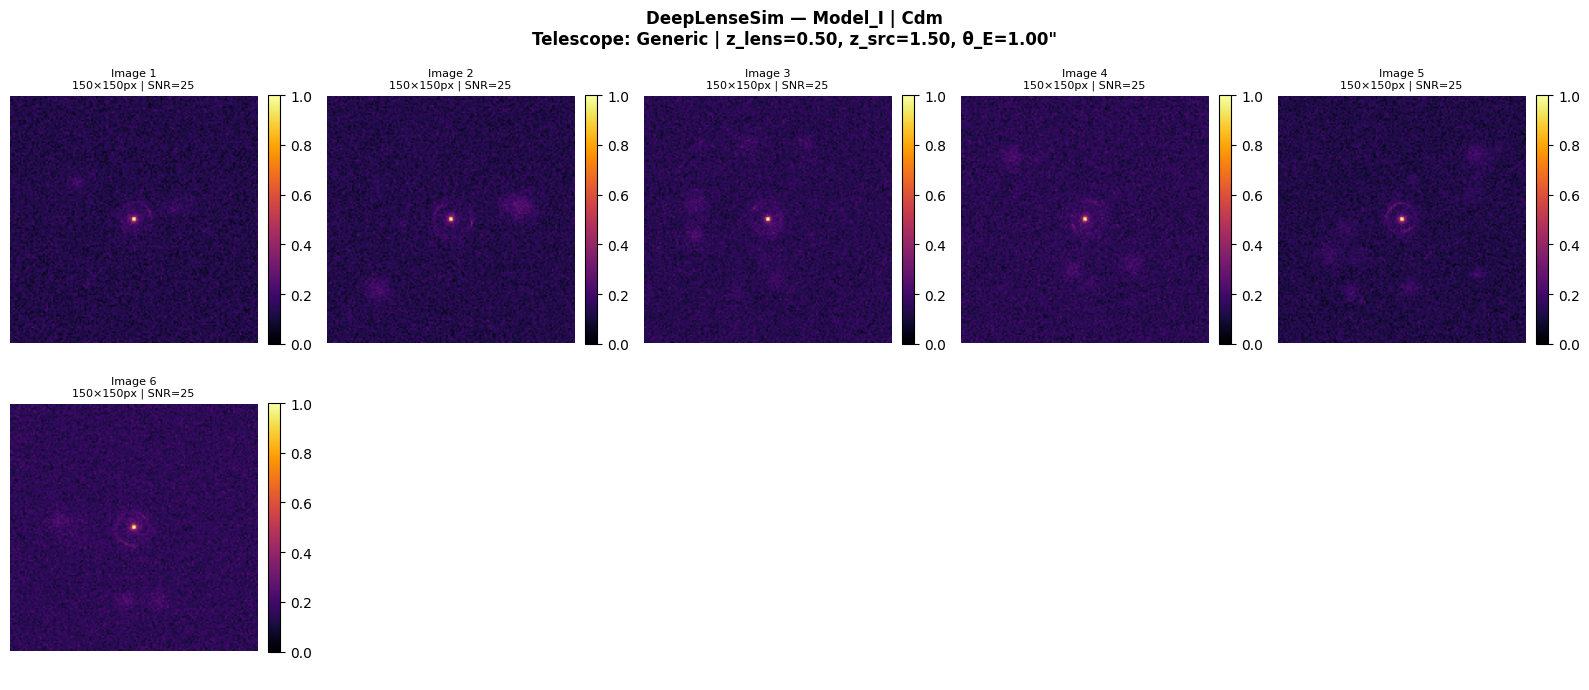

  ✓ Figure saved → Model_I_cdm_results.png

🔭 Agent: ✓ Done! 6 images in 3.8s
  Saved to: ./simulated_images/

───────────────────────────────────────────────────────
  Status:    success
  Model:     Model_I
  Class:     cdm
  Images:    6 × 150px
  Telescope: Generic
  Time:      0.33s


In [9]:
agent = DeepLenseAgent()

result_1 = agent.run(
    "Generate 6 strong lensing images with CDM subhalo substructure using Model_I. "
    "Set z_lens=0.5, z_source=1.5, Einstein radius 1.0 arcsec.",
    interactive=False,
)
print(f"\n{'─'*55}")
print(f"  Status:    {result_1.status}")
print(f"  Model:     {result_1.config_used.model_version.value}")
print(f"  Class:     {result_1.config_used.substructure_type.value}")
print(f"  Images:    {result_1.images_generated} × {result_1.config_used.obs_params.image_size}px")
print(f"  Telescope: {result_1.config_used.obs_params.telescope}")
print(f"  Time:      {result_1.total_time_seconds:.2f}s")



════════════════════════════════════════════════════════════
  🔭 DeepLense Simulation Agent
════════════════════════════════════════════════════════════

👤 User:  Simulate 5 gravitational lensing images with axion dark matter using Model_II (Euclid). Use z_lens=0.3, z_source=2.0.

🔭 Agent: Using Groq LLM (tool-dispatch mode)...
✓ Parsed config: Model: Model_II | Substructure: axion | Images: 5 | z_lens=0.3, z_src=2.0 | Size: 64px | Telescope: Euclid
  ✓ 5 images in 0.0s  →  ./simulated_images/


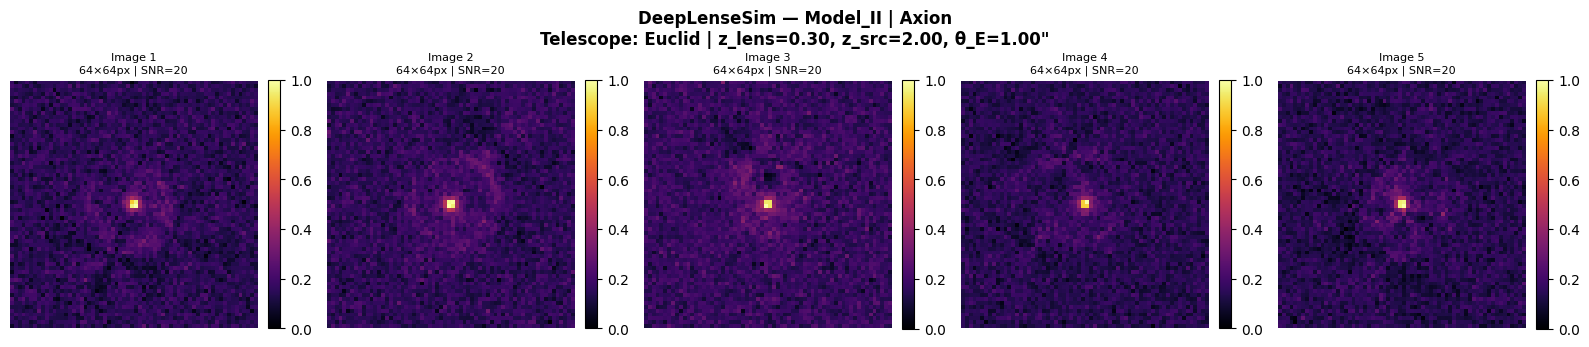

  ✓ Figure saved → Model_II_axion_results.png

🔭 Agent: ✓ Done! 5 images in 3.1s
  Saved to: ./simulated_images/

✓ Demo 2 — Model_II | axion | 5 images × 64px


In [10]:
result_2 = agent.run(
    "Simulate 5 gravitational lensing images with axion dark matter "
    "using Model_II (Euclid). Use z_lens=0.3, z_source=2.0.",
    interactive=False,
)
print(f"\n✓ Demo 2 — {result_2.config_used.model_version.value} | "
      f"{result_2.config_used.substructure_type.value} | "
      f"{result_2.images_generated} images × {result_2.config_used.obs_params.image_size}px")



════════════════════════════════════════════════════════════
  🔭 DeepLense Simulation Agent
════════════════════════════════════════════════════════════

👤 User:  Generate 4 clean lensing images with no substructure using HST (Model_III). z_lens=0.4, z_source=1.8.

🔭 Agent: Using Groq LLM (tool-dispatch mode)...
✓ Parsed config: Model: Model_III | Substructure: no_substructure | Images: 4 | z_lens=0.4, z_src=1.8 | Size: 64px | Telescope: HST
  ✓ 4 images in 0.0s  →  ./simulated_images/


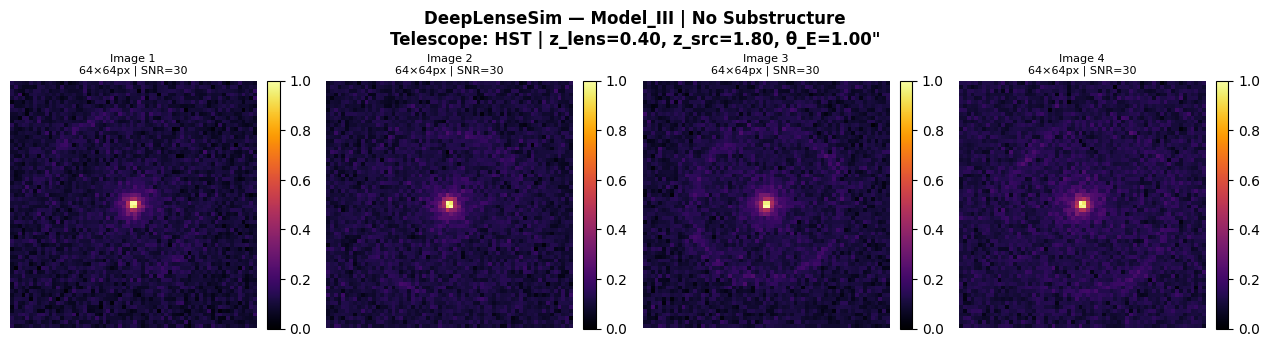

  ✓ Figure saved → Model_III_no_substructure_results.png

🔭 Agent: ✓ Done! 4 images in 2.9s
  Saved to: ./simulated_images/

════════════════════════════════════════════════════════════
  🔭 DeepLense Simulation Agent
════════════════════════════════════════════════════════════

👤 User:  Simulate 4 CDM subhalo images using Model_IV. z_lens=0.6, z_source=2.0.

🔭 Agent: Using Groq LLM (tool-dispatch mode)...
✓ Parsed config: Model: Model_IV | Substructure: cdm | Images: 4 | z_lens=0.6, z_src=2.0 | Size: 64px | Telescope: Euclid (real sources)
  ✓ 4 images in 0.0s  →  ./simulated_images/


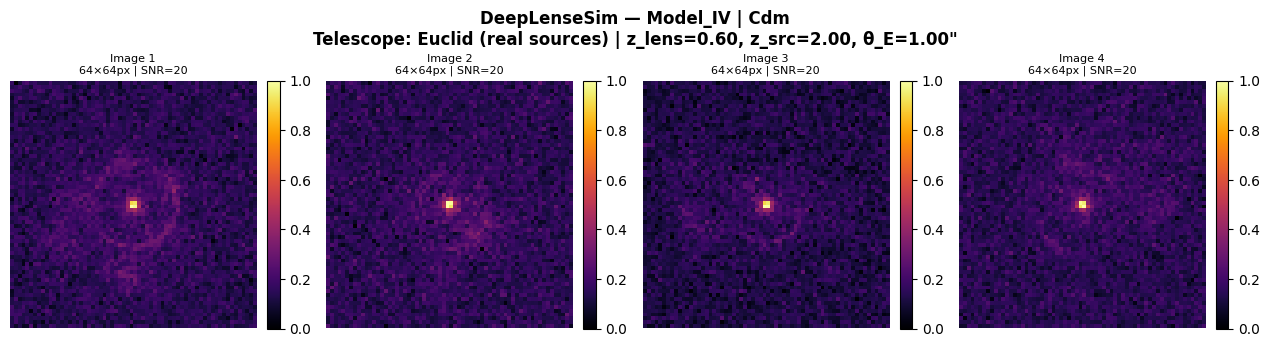

  ✓ Figure saved → Model_IV_cdm_results.png

🔭 Agent: ✓ Done! 4 images in 2.4s
  Saved to: ./simulated_images/

✓ Demo 3 — Model_III | no_substructure | 4 images
✓ Demo 4 — Model_IV | cdm | 4 images


In [11]:
result_3 = agent.run(
    "Generate 4 clean lensing images with no substructure using HST (Model_III). "
    "z_lens=0.4, z_source=1.8.",
    interactive=False,
)
result_4 = agent.run(
    "Simulate 4 CDM subhalo images using Model_IV. z_lens=0.6, z_source=2.0.",
    interactive=False,
)
print(f"\n✓ Demo 3 — {result_3.config_used.model_version.value} | "
      f"{result_3.config_used.substructure_type.value} | {result_3.images_generated} images")
print(f"✓ Demo 4 — {result_4.config_used.model_version.value} | "
      f"{result_4.config_used.substructure_type.value} | {result_4.images_generated} images")



════════════════════════════════════════════════════════════
  🔭 DeepLense Simulation Agent
════════════════════════════════════════════════════════════

👤 User:  I need fuzzy dark matter images from the Euclid telescope with real galaxy backgrounds. 5 images please.

🔭 Agent: Using Groq LLM (tool-dispatch mode)...
✓ Parsed config: Model: Model_IV | Substructure: axion | Images: 5 | z_lens=0.5, z_src=1.5 | Size: 64px | Telescope: Euclid (real sources)
  ✓ 5 images in 0.0s  →  ./simulated_images/

🔭 Agent: I'll run the following simulation — please confirm:
   📌 Model:        Model_IV
   📌 Telescope:    Euclid (real sources)
   📌 Substructure: axion
   📌 # Images:     5
   📌 z_lens:       0.5
   📌 z_source:     1.5
   📌 Einstein θ_E: 1.0 arcsec
   📌 Image size:   64×64 px
   📌 SNR:          20.0

   Type  yes / no / edit


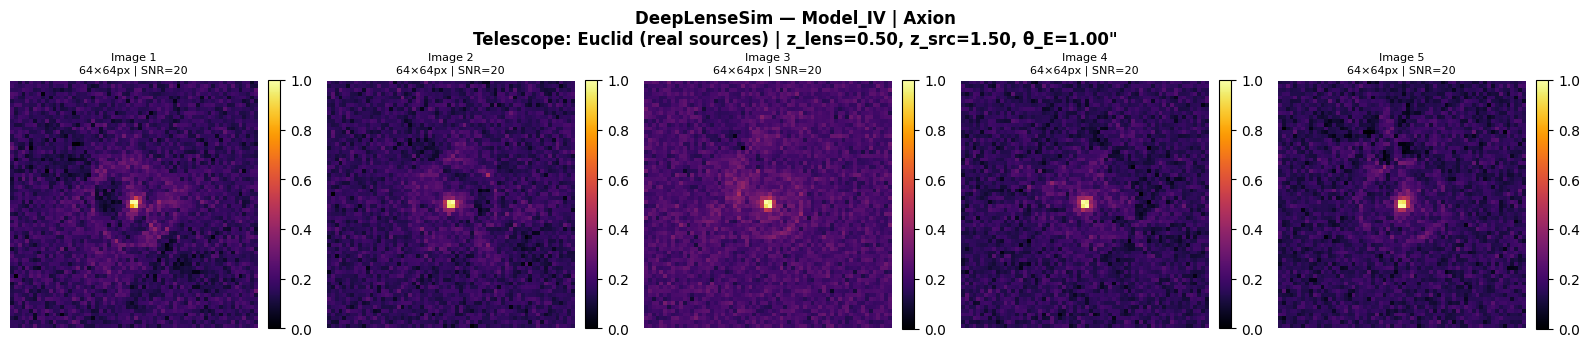

  ✓ Figure saved → Model_IV_axion_results.png

🔭 Agent: ✓ Done! 5 images in 8.3s
  Saved to: ./simulated_images/

✓ Done: success — 5 images
  Reasoning: Direct fallback after LLM output parse failure


In [ ]:
interactive_agent = DeepLenseAgent()
user_prompt = input("\n🌌 Enter your simulation request: ").strip()
if user_prompt:
    result = interactive_agent.run(user_prompt, interactive=True)
    print(f"\n✓ Done: {result.status} — {result.images_generated} images")
    print(f"  Reasoning: {result.agent_reasoning}")
else:
    print("No prompt entered.")


In [17]:
print('Output Validation Report')
print('=' * 60)
for i, result in enumerate([result_1, result_2, result_3, result_4], 1):
    cfg = result.config_used
    print(f'\nDemo {i}: {cfg.model_version.value} | {cfg.substructure_type.value}')
    print(f'  Status:       {result.status}')
    print(f'  Images:       {result.images_generated}')
    print(f'  Size:         {cfg.obs_params.image_size}×{cfg.obs_params.image_size}px')
    print(f'  Telescope:    {cfg.obs_params.telescope}')
    print(f'  Config valid: {SimulationConfig.model_validate(cfg.model_dump()) is not None}')
    print(f'  Metadata OK:  {len(result.images_metadata) == result.images_generated}')
    all_saved = all(
        os.path.exists(os.path.join(result.output_directory, m.filename))
        for m in result.images_metadata
    )
    print(f'  .npy saved:   {all_saved}')
    if result.warnings: print(f'  Warnings:     {result.warnings}')

print('\nGenerated .npy files:')
output_dir = './simulated_images'
if os.path.exists(output_dir):
    files = sorted(os.listdir(output_dir))
    for f in files:
        sz = os.path.getsize(os.path.join(output_dir, f))
        print(f'  {f:55s} ({sz/1024:.1f} KB)')
    print(f'\nTotal: {len(files)} files')


Output Validation Report

Demo 1: Model_I | cdm
  Status:       success
  Images:       6
  Size:         150×150px
  Telescope:    Generic
  Config valid: True
  Metadata OK:  True
  .npy saved:   True

Demo 2: Model_II | axion
  Status:       success
  Images:       5
  Size:         64×64px
  Telescope:    Euclid
  Config valid: True
  Metadata OK:  True
  .npy saved:   True

Demo 3: Model_III | no_substructure
  Status:       success
  Images:       4
  Size:         64×64px
  Telescope:    HST
  Config valid: True
  Metadata OK:  True
  .npy saved:   True

Demo 4: Model_IV | cdm
  Status:       success
  Images:       4
  Size:         64×64px
  Telescope:    Euclid (real sources)
  Config valid: True
  Metadata OK:  True
  .npy saved:   True

Generated .npy files:
  Model_III_axion_0001.npy                                (16.1 KB)
  Model_III_axion_0002.npy                                (16.1 KB)
  Model_III_axion_0003.npy                                (16.1 KB)
  Model_III_axi